In [1]:
import pandas as pd
import numpy as np
import os
import ast

# Utils

* dataset split concatenation
* dataset concatenation
* scenario expected value

In [2]:
def interleave_rows(df0, df1, m, n):
    df_merged = pd.DataFrame()
    
    max_len = max(len(df0), len(df1))
    
    for i in range(0, max_len, m):
        rows_from_df0 = df0.iloc[i : i + m]
        rows_from_df1 = df1.iloc[i : i + n]
        df_merged = pd.concat([df_merged, rows_from_df0, rows_from_df1], ignore_index=True)
    
    return df_merged.reset_index(drop=True)

In [7]:

num_scenario = 100
base_dir = "../datasets/Independent Scenarios/SRP data"


file_split0 = os.path.join(base_dir, f"SRP_dataset.csv")
file_split1 = os.path.join(base_dir, f"SRP_dataset_half2.csv")
df0 = pd.read_csv(file_split0)
df1 = pd.read_csv(file_split1)



df_merged = interleave_rows(df0=df0, df1=df1, m=num_scenario, n=num_scenario)
df_merged = df_merged.loc[:, ~df_merged.columns.str.startswith('Unnamed')]

output_file = os.path.join(base_dir, f"SRP_dataset_tmp.csv")
df_merged.to_csv(output_file, index=False)

In [ ]:
num_scenario_base = 150
num_scenario_new = 50
base_dir = "../datasets/Independent Scenarios/SRP data"

base_df = pd.read_csv(os.path.join(base_dir, f"SRP_dataset.csv"))
new_df = pd.read_csv(os.path.join(base_dir, f"SRP_dataset_newScen.csv"))


df_merged = interleave_rows(df0=base_df, df1=new_df, m=num_scenario_base, n=num_scenario_new)
df_merged = df_merged.loc[:, ~df_merged.columns.str.startswith('Unnamed')]

output_file = os.path.join(base_dir, f"SRP_dataset.csv")
df_merged.to_csv(output_file, index=False)

In [3]:
scen_df = pd.read_csv('../scenarios/scenario_dataset_cumulate.csv')
df = pd.read_csv('../datasets/Independent Scenarios/SRP data/SRP_dataset_tmp.csv')
num_scenarios = 50
num_dataset = 20
num_solutions = 10012
num_scenario_total = df['scenario'].max() +1
df['solution'] = (df.index // num_scenario_total)
scen_df_tmp = scen_df[scen_df['scenario_number'] == num_scenarios]

for d in range(num_dataset):
   scenario_set = scen_df_tmp[scen_df_tmp['dataset_id'] == d]['indexes'].iloc[0]
   index_list = ast.literal_eval(scenario_set)
   training_dataset = pd.DataFrame()
   for n in range(num_solutions):
      df_tmp = df[df['solution'] == n]
      df_tmp = df_tmp.set_index('scenario')
      df_tmp = df_tmp.loc[index_list]
      expected_val = np.mean(df_tmp['ope_cost'])
      row = df_tmp.iloc[0].copy()
      row['ope_cost'] = expected_val
      row = pd.DataFrame([row])
      training_dataset = pd.concat([training_dataset, row], ignore_index=True)
   training_dataset.to_csv(f'../datasets/Independent Scenarios/SRP_{num_scenarios}_scenario_{d}.csv') 

# check dataset structure

In [1]:
import matplotlib.pyplot as plt

In [3]:
solutions = pd.read_csv('../Random solutions/random_solutions.csv')
len(solutions)

10012

In [4]:
solutions

,Unnamed: 0,node,0,1,2,3,4,5,6,7,8,9,10,ope_cost,co2_budget,co2_price,demand_scaling,ope_node
0,0,10,93.059791,28.272727,9.611313,28.078275,7.099495,6.492895,3.646100,0.5,18.512961,13.405937,19.156104,NaN,28566.7350,0.018,-1.15,10.0
1,1,1,12.599991,2.000000,7.200000,23.282819,46.772727,6.649991,4.620828,0.5,45.320661,14.111513,20.164320,NaN,45706.7760,0.018,-1.10,1.0
2,2,9,13.211306,5.090909,6.480000,32.775244,4.050000,6.317491,3.646100,0.5,18.512961,13.405937,45.772266,NaN,31423.4085,0.018,-1.25,9.0
3,3,10,10.079993,2.000000,6.480000,20.249992,28.445960,6.580597,8.343070,0.5,18.512961,13.405937,19.156104,NaN,28566.7350,0.018,-1.15,10.0
4,4,2,12.599991,7.479798,26.770707,22.499991,4.500000,6.649991,3.838000,0.5,29.664095,14.111513,23.295633,NaN,39993.4290,0.018,-1.00,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10007,10007,7,10.079993,2.000000,6.480000,20.249992,4.050000,6.317491,3.646100,0.5,18.512961,13.405937,19.156104,NaN,34280.0820,0.018,-1.25,NaN
10008,10008,8,10.079993,2.000000,6.480000,20.249992,4.050000,6.317491,3.646100,0.5,18.512961,13.405937,19.156104,NaN,31423.4085,0.018,-1.15,NaN
10009,10009,9,10.079993,2.000000,6.480000,20.249992,4.050000,6.317491,3.646100,0.5,18.512961,13.405937,19.156104,NaN,31423.4085,0.018,-1.25,NaN
10010,10010,10,10.079993,2.000000,6.480000,20.249992,4.050000,6.317491,3.646100,0.5,18.512961,13.405937,19.156104,NaN,28566.7350,0.018,-1.15,NaN


In [6]:
base = solutions.iloc[10000:10012]
columns = [str(i) for i in range(11)]  

df_merged = solutions.merge(base, on='node', suffixes=('', '_ref'))

for col in columns:
    df_merged[col] = df_merged[col] - df_merged[f"{col}_ref"]

df_result = df_merged[['node'] + columns]

In [7]:
df_result['cumulated_inv'] = df_result[[str(i) for i in range(11)]].sum(axis=1)

C:\Users\gabri\AppData\Local\Temp\ipykernel_440\549791126.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result['cumulated_inv'] = df_result[[str(i) for i in range(11)]].sum(axis=1)


In [12]:
df_tmp = df_result[df_result['node'] < 3]
len(df_tmp[df_tmp['cumulated_inv'] > 77.50001])

0

In [13]:
df_tmp = df_result[df_result['node'] > 3]
len(df_tmp[df_tmp['cumulated_inv'] > 77.50001])

3445

In [13]:
df_scen = pd.read_csv('../datasets/SRP 10 scenario 1/scenarios_SRP_10.csv')
df = pd.read_csv('../datasets/SRP 10 scenario 1/SRP_10_scenario_18.csv')

In [14]:
df_scen

,Unnamed: 0,num_scenarios,dataset_index,scenarios_index
0,0,10,0,"[16, 7, 17, 13, 2, 11, 3, 5, 9, 15]"
1,1,10,1,"[2, 17, 4, 12, 16, 5, 3, 1, 0, 11]"
2,2,10,2,"[14, 16, 9, 4, 18, 11, 13, 19, 1, 17]"
3,3,10,3,"[9, 14, 11, 2, 5, 15, 0, 16, 17, 4]"
4,4,10,4,"[6, 14, 13, 7, 9, 19, 12, 4, 15, 17]"
5,5,10,5,"[17, 1, 6, 16, 9, 0, 4, 18, 7, 19]"
6,6,10,6,"[5, 17, 8, 18, 9, 14, 2, 6, 16, 1]"
7,7,10,7,"[3, 13, 18, 2, 8, 16, 1, 5, 7, 9]"
8,8,10,8,"[13, 5, 15, 0, 9, 19, 6, 3, 4, 1]"
9,9,10,9,"[5, 17, 12, 8, 14, 1, 9, 6, 11, 15]"


In [15]:
df

,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,co2_budget,co2_price,demand_scaling,group_id,node,ope_cost
0,0,10.079993,2.0,53.449697,111.058073,4.050000,6.317491,3.646100,13.025253,18.512961,13.405937,23.853074,33199.3376,0.018,-1.25,0.0,6.0,376007.619691
1,1,13.382819,2.0,7.200000,47.550496,6.848485,7.830800,5.403657,38.075758,19.487327,14.111513,28.775431,40860.7232,0.018,-1.10,1.0,2.0,100158.049777
2,2,25.736558,2.0,42.490101,20.249992,5.574747,6.317491,5.211757,0.500000,84.270537,46.284725,20.721761,25537.9520,0.018,-1.15,2.0,11.0,15536.640551
3,3,113.413326,2.0,29.964848,20.249992,14.723232,8.334640,11.474383,0.500000,24.775587,13.405937,19.156104,25537.9520,0.018,-1.15,3.0,11.0,261303.749262
4,4,10.079993,2.0,81.631515,20.249992,14.723232,14.473787,3.646100,0.500000,18.512961,72.900887,19.156104,33199.3376,0.018,-1.25,4.0,6.0,8261.446322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15019,15019,10.079993,2.0,6.480000,20.249992,4.050000,6.317491,3.646100,0.500000,18.512961,13.405937,19.156104,33199.3376,0.018,-1.35,15019.0,7.0,485225.187864
15020,15020,10.079993,2.0,6.480000,20.249992,4.050000,6.317491,3.646100,0.500000,18.512961,13.405937,19.156104,30645.5424,0.018,-1.25,15020.0,8.0,412504.625031
15021,15021,10.079993,2.0,6.480000,20.249992,4.050000,6.317491,3.646100,0.500000,18.512961,13.405937,19.156104,28091.7472,0.018,-1.15,15021.0,9.0,340137.708337
15022,15022,10.079993,2.0,6.480000,20.249992,4.050000,6.317491,3.646100,0.500000,18.512961,13.405937,19.156104,28091.7472,0.018,-1.25,15022.0,10.0,434704.334958


In [ ]:
df['ope_cost'].describe()

count     15024.000000
mean     120417.980782
std      144949.519668
min        1306.461704
25%        6546.761072
50%       41135.011410
75%      206754.223908
max      535899.603946
Name: ope_cost, dtype: float64

: 

In [14]:
df = pd.read_csv('../datasets/SRP 10 scenario 3/SRP_10_scenario.csv')
df

,Unnamed: 0.1,Unnamed: 0,node,0,1,2,3,4,5,6,7,8,9,10,ope_cost,co2_budget,co2_price,demand_scaling,ope_node
0,0,0,6,10.079993,2.0,53.449697,111.058073,4.050000,6.317491,3.646100,13.025253,18.512961,13.405937,23.853074,359273.664810,33199.3376,0.018,-1.25,6.0
1,1,1,2,13.382819,2.0,7.200000,47.550496,6.848485,7.830800,5.403657,38.075758,19.487327,14.111513,28.775431,84193.248459,40860.7232,0.018,-1.10,2.0
2,2,2,11,25.736558,2.0,42.490101,20.249992,5.574747,6.317491,5.211757,0.500000,84.270537,46.284725,20.721761,2270.519956,25537.9520,0.018,-1.15,11.0
3,3,3,11,113.413326,2.0,29.964848,20.249992,14.723232,8.334640,11.474383,0.500000,24.775587,13.405937,19.156104,242212.263765,25537.9520,0.018,-1.15,11.0
4,4,4,6,10.079993,2.0,81.631515,20.249992,14.723232,14.473787,3.646100,0.500000,18.512961,72.900887,19.156104,4199.273075,33199.3376,0.018,-1.25,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15019,15019,7507,7,10.079993,2.0,6.480000,20.249992,4.050000,6.317491,3.646100,0.500000,18.512961,13.405937,19.156104,466999.349752,33199.3376,0.018,-1.35,NaN
15020,15020,7508,8,10.079993,2.0,6.480000,20.249992,4.050000,6.317491,3.646100,0.500000,18.512961,13.405937,19.156104,395285.673497,30645.5424,0.018,-1.25,NaN
15021,15021,7509,9,10.079993,2.0,6.480000,20.249992,4.050000,6.317491,3.646100,0.500000,18.512961,13.405937,19.156104,323838.611868,28091.7472,0.018,-1.15,NaN
15022,15022,7510,10,10.079993,2.0,6.480000,20.249992,4.050000,6.317491,3.646100,0.500000,18.512961,13.405937,19.156104,417485.383424,28091.7472,0.018,-1.25,NaN


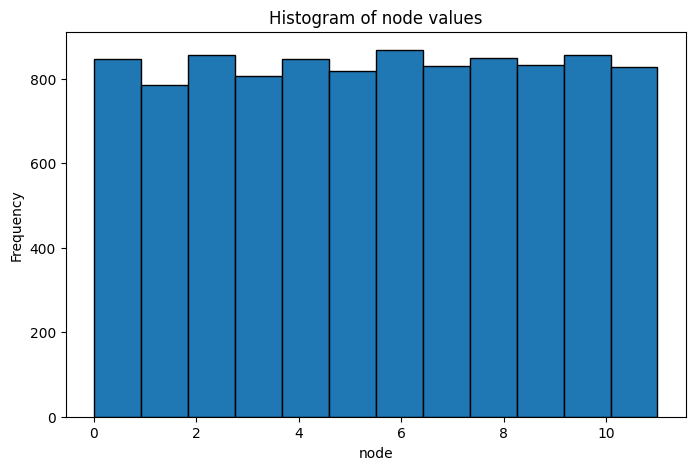

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df['node'], bins=12, edgecolor='black')
plt.title('Histogram of node values')
plt.xlabel('node')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

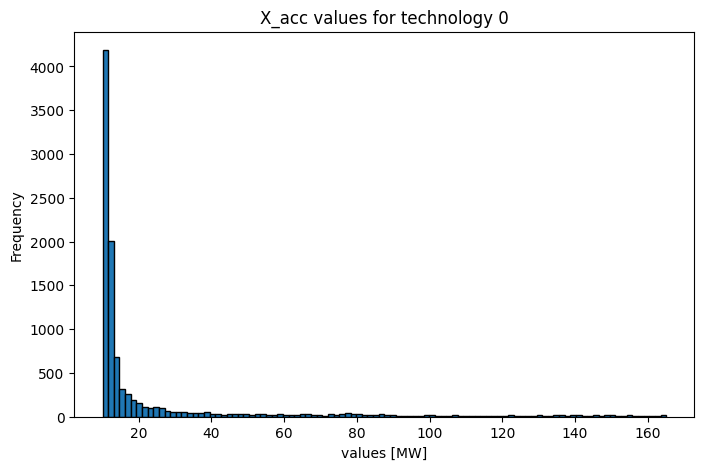

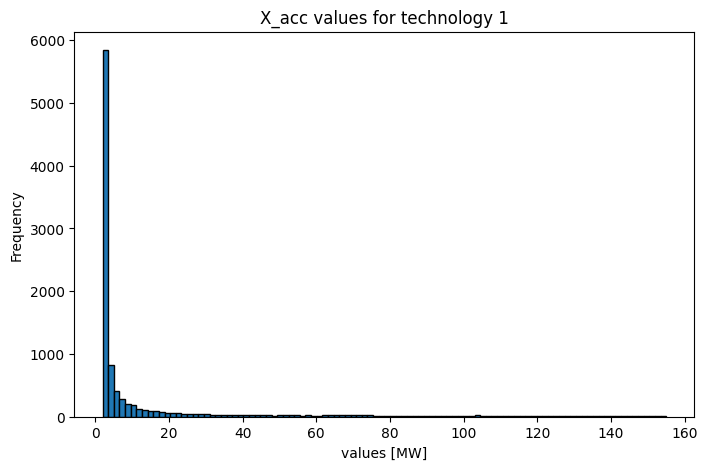

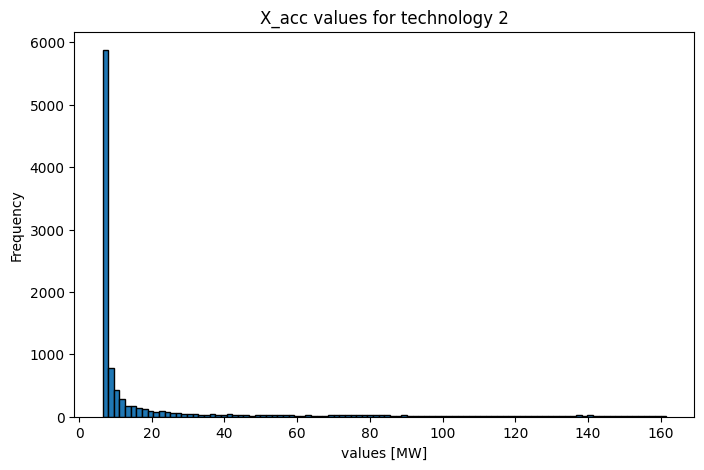

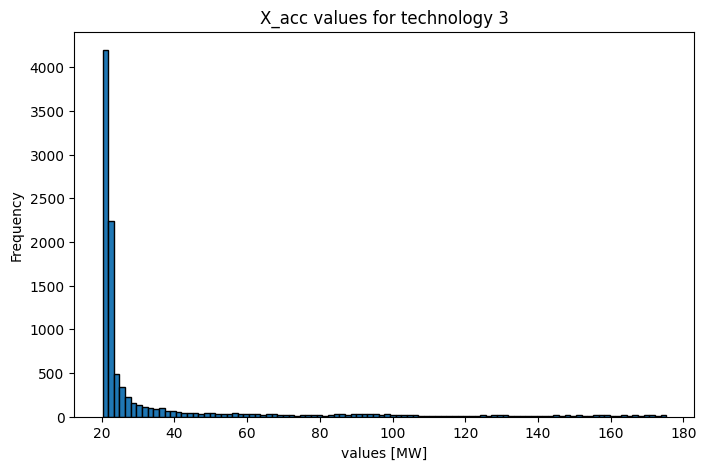

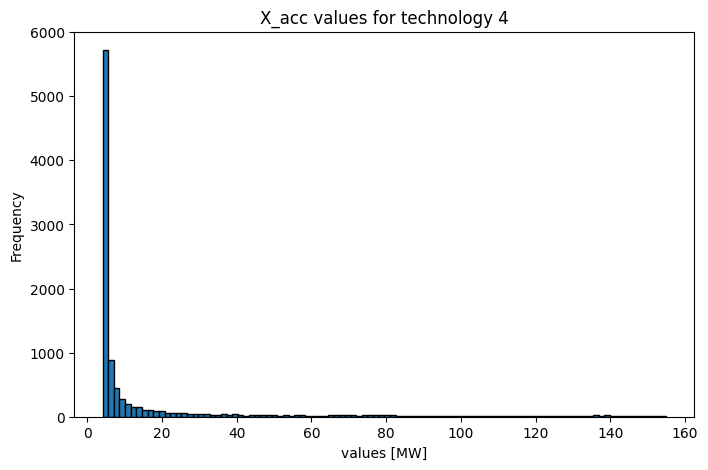

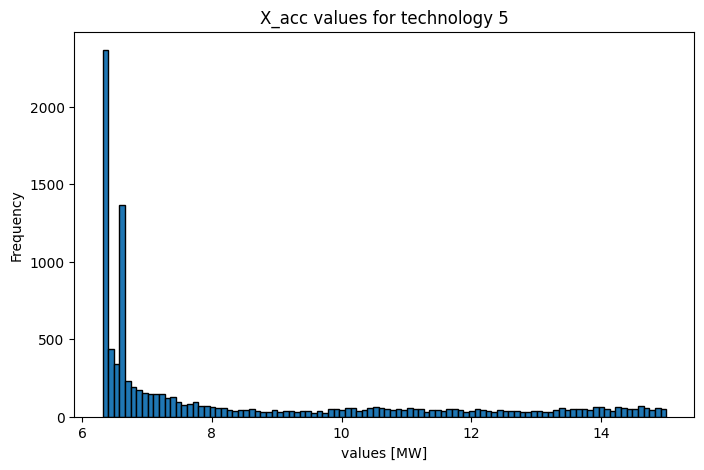

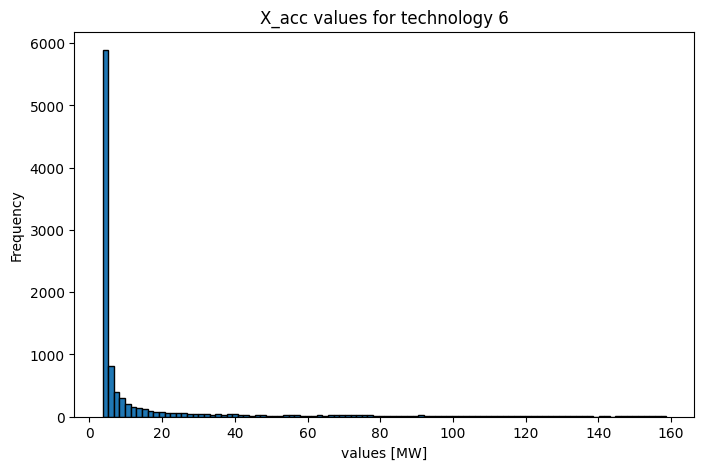

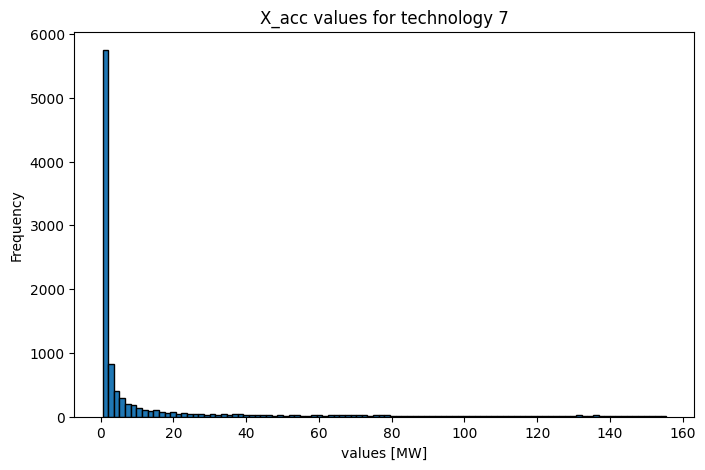

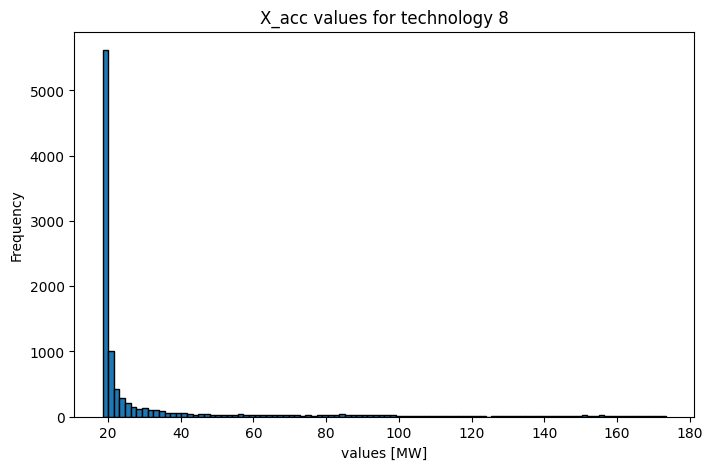

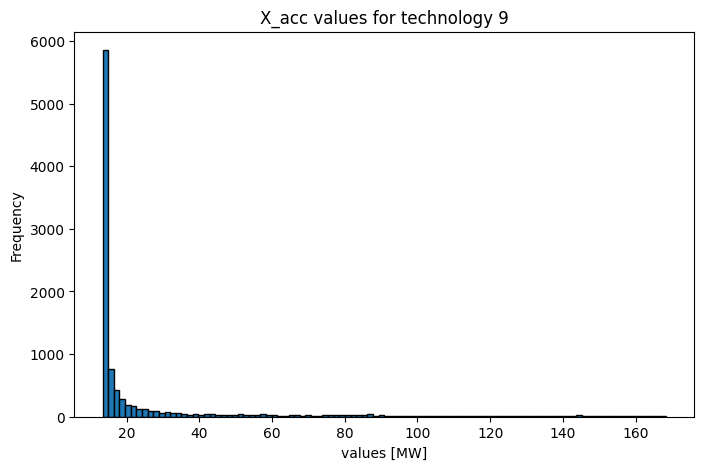

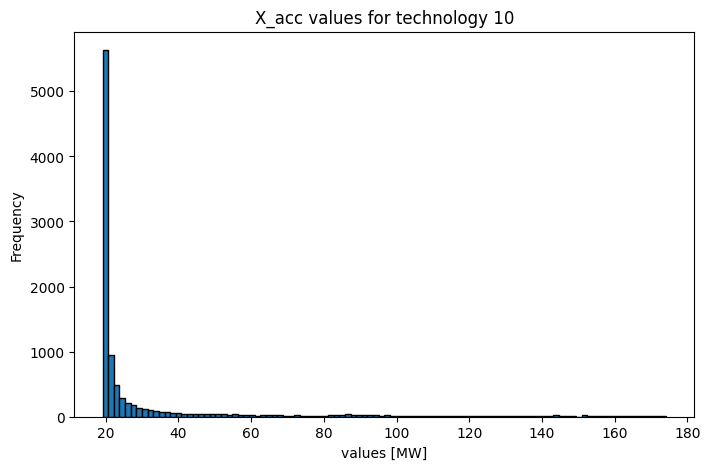

In [8]:
for tech_idx in range(11):
    plt.figure(figsize=(8, 5))
    plt.hist(df[str(tech_idx)], bins=100, edgecolor='black')
    plt.title(f'X_acc values for technology {tech_idx}')
    plt.xlabel('values [MW]')
    plt.ylabel('Frequency')
    plt.grid(False)
    plt.show()

In [31]:
df['ope_cost'].describe()

count     10024.000000
mean     133190.922559
std      150816.525967
min        1132.252111
25%        8505.218638
50%       58509.397116
75%      222096.013843
max      552381.036159
Name: ope_cost, dtype: float64

In [32]:
from OperationalSubProblem import OperationalSubProblem
from pyomo.environ import *

df_tmp = df.iloc[:4]
df_tmp['ope_cost'] = None

df_tmp = df_tmp.loc[df_tmp.index.repeat(10)].reset_index(drop=True)
df_tmp['scenario_index'] = np.tile(np.arange(10), int(np.ceil(len(df_tmp)/10)))[:len(df_tmp)]
    

P_accg = df_tmp[['0','1','2','3','4','5']]
P_accSE = df_tmp[['6','7']]
P_accr = df_tmp[['8','9','10']]

scenario_set = np.load('scenarios/scenarios.npy')
scenarios = scenario_set[:10]

for index, row in df_tmp.iterrows():
    
    model_instance = OperationalSubProblem(scenarios[row['scenario_index']])
    model = model_instance.get_model()
    opt = SolverFactory("gurobi_direct")
    
    for g in model.G:
        model.p_accG[g].fix(P_accg[str(g)].iloc[index])
        for t in model.T:
            model.p_G[g,t].setub(P_accg[str(g)].iloc[index])
    
    for s in model.S:
        model.p_accSE[s].fix(P_accSE[str(s+6)].iloc[index])
        for t in model.T:
            model.p_SEm[s,t].setub(P_accSE[str(s+6)].iloc[index])
            model.p_SEp[s,t].setub(P_accSE[str(s+6)].iloc[index])
            model.q_SE[s,t].setub(P_accSE[str(s+6)].iloc[index] * model.gamma_se[s])
            
            
    
    for r in model.R:
        model.p_accR[r].fix(P_accr[str(r+8)].iloc[index])
    
    model.mu_dp.set_value(df_tmp['demand_scaling'].iloc[index])
    model.mu_e.set_value((df_tmp['co2_budget'].iloc[index]))
    #model.c_co2.set_value(df_tmp['co2_price'].iloc[index])
    
    result = opt.solve(model)

    
    if result.solver.termination_condition == TerminationCondition.infeasible:
        print('infeasible at index', index)
        df_tmp.at[index, 'ope_cost'] = -1
    else:
        ope_value = float(value(model.objective))
        df_tmp.at[index, 'ope_cost'] = ope_value

    for var in model.component_data_objects(Var, active=True):
        var.unfix()
        var.value = None

C:\Users\gabri\AppData\Local\Temp\ipykernel_11412\538553308.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['ope_cost'] = None


In [33]:
len(df_tmp)

40

In [34]:
df_tmp.iloc[30:40]['ope_cost'].mean()

np.float64(306190.9206529514)

In [ ]:
from OperationalSubProblem import OperationalSubProblemMulti
from pyomo.environ import *

df_tmp = df.iloc[:4]
df_tmp['ope_cost'] = None

P_accg = df_tmp[['0','1','2','3','4','5']]
P_accSE = df_tmp[['6','7']]
P_accr = df_tmp[['8','9','10']]

scenario_set = np.load('scenarios/scenarios.npy')
scenarios = scenario_set[:10]
print(len(scenarios))

for index, row in df_tmp.iterrows():
    
    model_instance = OperationalSubProblemMulti(scenarios)
    model = model_instance.get_model()
    opt = SolverFactory("gurobi_direct")
    
    for g in model.G:
        model.p_accG[g].fix(P_accg[str(g)].iloc[index])
        for t in model.T:
            model.p_G[g,t].setub(P_accg[str(g)].iloc[index])
    
    for s in model.S:
        model.p_accSE[s].fix(P_accSE[str(s+6)].iloc[index])
        for t in model.T:
            model.p_SEm[s,t].setub(P_accSE[str(s+6)].iloc[index])
            model.p_SEp[s,t].setub(P_accSE[str(s+6)].iloc[index])
            model.q_SE[s,t].setub(P_accSE[str(s+6)].iloc[index] * model.gamma_se[s])
            
            
    
    for r in model.R:
        model.p_accR[r].fix(P_accr[str(r+8)].iloc[index])
    
    model.mu_dp.set_value(df_tmp['demand_scaling'].iloc[index])
    model.mu_e.set_value((df_tmp['co2_budget'].iloc[index]))
    #model.c_co2.set_value(df_tmp['co2_price'].iloc[index])
    
    result = opt.solve(model)

    
    if result.solver.termination_condition == TerminationCondition.infeasible:
        print('infeasible at index', index)
        df_tmp.at[index, 'ope_cost'] = -1
    else:
        ope_value = float(value(model.objective))
        df_tmp.at[index, 'ope_cost'] = ope_value

    for var in model.component_data_objects(Var, active=True):
        var.unfix()
        var.value = None

C:\Users\gabri\AppData\Local\Temp\ipykernel_3032\916295067.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['ope_cost'] = None


10


In [6]:
df_tmp

,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,co2_budget,demand_scaling,co2_price,group_id,node,ope_cost
0,0,16.342619,2.000000,8.045657,21.815648,4.050000,6.405193,20.868322,14.590909,26.341244,33.759473,103.701559,38306.9280,-1.45,0.018,0.0,4.0,142849.774851
1,1,46.090094,74.636364,6.480000,26.512618,7.099495,14.649192,5.211757,9.893939,24.775587,19.668563,23.853074,30645.5424,-1.25,0.018,1.0,8.0,7458.401693
2,2,12.599991,6.696970,15.811111,22.499991,4.500000,14.072221,3.838000,38.858586,33.578236,18.025654,20.164320,45968.3136,-1.20,0.018,2.0,1.0,6765.104632
3,3,10.079993,6.636364,6.480000,20.249992,4.050000,6.317491,146.120847,5.196970,18.512961,13.405937,22.287417,25537.9520,-1.15,0.018,3.0,11.0,306190.920653


In [37]:
df_tmp.iloc[0]['ope_cost']

142849.77485144295

In [2]:
df = pd.read_csv('datasets/SRP 10 scenario 3/SRP_10_scenario.csv')

In [3]:
df

,Unnamed: 0.1,Unnamed: 0,node,0,1,2,3,4,5,6,7,8,9,10,ope_cost,co2_budget,co2_price,demand_scaling,ope_node
0,0,0,6,10.079993,2.0,53.449697,111.058073,4.050000,6.317491,3.646100,13.025253,18.512961,13.405937,23.853074,359273.664810,33199.3376,0.018,-1.25,6.0
1,1,1,2,13.382819,2.0,7.200000,47.550496,6.848485,7.830800,5.403657,38.075758,19.487327,14.111513,28.775431,84193.248459,40860.7232,0.018,-1.10,2.0
2,2,2,11,25.736558,2.0,42.490101,20.249992,5.574747,6.317491,5.211757,0.500000,84.270537,46.284725,20.721761,2270.519956,25537.9520,0.018,-1.15,11.0
3,3,3,11,113.413326,2.0,29.964848,20.249992,14.723232,8.334640,11.474383,0.500000,24.775587,13.405937,19.156104,242212.263765,25537.9520,0.018,-1.15,11.0
4,4,4,6,10.079993,2.0,81.631515,20.249992,14.723232,14.473787,3.646100,0.500000,18.512961,72.900887,19.156104,4199.273075,33199.3376,0.018,-1.25,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15019,15019,7507,7,10.079993,2.0,6.480000,20.249992,4.050000,6.317491,3.646100,0.500000,18.512961,13.405937,19.156104,466999.349752,33199.3376,0.018,-1.35,NaN
15020,15020,7508,8,10.079993,2.0,6.480000,20.249992,4.050000,6.317491,3.646100,0.500000,18.512961,13.405937,19.156104,395285.673497,30645.5424,0.018,-1.25,NaN
15021,15021,7509,9,10.079993,2.0,6.480000,20.249992,4.050000,6.317491,3.646100,0.500000,18.512961,13.405937,19.156104,323838.611868,28091.7472,0.018,-1.15,NaN
15022,15022,7510,10,10.079993,2.0,6.480000,20.249992,4.050000,6.317491,3.646100,0.500000,18.512961,13.405937,19.156104,417485.383424,28091.7472,0.018,-1.25,NaN


In [5]:
base = df.iloc[15012:15024]
base

,Unnamed: 0.1,Unnamed: 0,node,0,1,2,3,4,5,6,7,8,9,10,ope_cost,co2_budget,co2_price,demand_scaling,ope_node
15012,15012,7500,0,12.599991,2.0,7.20,22.499991,4.50,6.649991,3.8380,0.5,19.487327,14.111513,20.164320,6033.674776,51075.9040,0.018,-1.00,NaN
15013,15013,7501,1,12.599991,2.0,7.20,22.499991,4.50,6.649991,3.8380,0.5,19.487327,14.111513,20.164320,190294.358135,45968.3136,0.018,-1.20,NaN
15014,15014,7502,2,12.599991,2.0,7.20,22.499991,4.50,6.649991,3.8380,0.5,19.487327,14.111513,20.164320,141456.029802,40860.7232,0.018,-1.10,NaN
15015,15015,7503,3,10.079993,2.0,6.48,20.249992,4.05,6.317491,3.6461,0.5,18.512961,13.405937,19.156104,117607.224377,35753.1328,0.018,-1.00,NaN
15016,15016,7504,4,10.079993,2.0,6.48,20.249992,4.05,6.317491,3.6461,0.5,18.512961,13.405937,19.156104,516644.676751,38306.9280,0.018,-1.45,NaN
15017,15017,7505,5,10.079993,2.0,6.48,20.249992,4.05,6.317491,3.6461,0.5,18.512961,13.405937,19.156104,444799.639825,35753.1328,0.018,-1.35,NaN
15018,15018,7506,6,10.079993,2.0,6.48,20.249992,4.05,6.317491,3.6461,0.5,18.512961,13.405937,19.156104,373085.963570,33199.3376,0.018,-1.25,NaN
15019,15019,7507,7,10.079993,2.0,6.48,20.249992,4.05,6.317491,3.6461,0.5,18.512961,13.405937,19.156104,466999.349752,33199.3376,0.018,-1.35,NaN
15020,15020,7508,8,10.079993,2.0,6.48,20.249992,4.05,6.317491,3.6461,0.5,18.512961,13.405937,19.156104,395285.673497,30645.5424,0.018,-1.25,NaN
15021,15021,7509,9,10.079993,2.0,6.48,20.249992,4.05,6.317491,3.6461,0.5,18.512961,13.405937,19.156104,323838.611868,28091.7472,0.018,-1.15,NaN


In [7]:
colonne = [str(i) for i in range(11)]  


df_merged = df.merge(base, on='node', suffixes=('', '_ref'))

for col in colonne:
    df_merged[col] = df_merged[col] - df_merged[f"{col}_ref"]

df_result = df_merged[['node'] + colonne]

In [9]:
df_result[df_result['node'] == 0]

,node,0,1,2,3,4,5,6,7,8,9,10
13,0,0.000000,0.000000,0.000000,61.843434,0.000000,8.012635,7.045455,0.000000,0.000000,0.000000,0.000000
17,0,0.000000,9.393939,0.000000,0.782828,0.000000,0.000000,31.313131,0.000000,11.742424,24.267677,0.000000
27,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.253031,0.000000,0.000000,0.000000,0.000000,76.717172
43,0,0.782828,0.782828,0.000000,21.136364,0.000000,6.157078,0.000000,0.782828,47.752525,0.000000,0.000000
46,0,0.000000,5.479798,55.580808,1.565657,0.000000,0.168687,0.000000,2.348485,11.742424,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
14903,0,0.000000,0.782828,0.000000,0.000000,1.565657,0.000000,69.671717,0.000000,0.782828,0.000000,4.696970
14942,0,47.752525,0.000000,21.919192,0.000000,0.000000,0.000000,0.000000,1.565657,0.000000,2.348485,3.914141
14964,0,0.000000,0.000000,0.000000,0.000000,22.702020,0.000000,3.914141,21.919192,0.000000,28.964646,0.000000
14999,0,2.348485,9.393939,3.131313,3.131313,3.914141,0.759092,3.914141,2.348485,0.000000,45.404040,3.131313


In [12]:
df_result['somma'] = df_result[[str(i) for i in range(11)]].sum(axis=1)

C:\Users\gabri\AppData\Local\Temp\ipykernel_14588\936173705.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result['somma'] = df_result[[str(i) for i in range(11)]].sum(axis=1)


In [16]:
df_result[df_result['somma'] < 73]

,node,0,1,2,3,4,5,6,7,8,9,10,somma
7500,0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
7501,1,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
7502,2,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
7503,3,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
7504,4,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
7505,5,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
7506,6,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
7507,7,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
7508,8,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
7509,9,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
